Object: The goal is to build an intelligent classification system that categorizes messy, free-text support tickets into specific departments (e.g., Billing, Technical Support, Account Recovery).

Install Libraries

In [2]:
!pip install groq pandas matplotlib seaborn scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.3/142.3 kB 3.6 MB/s eta 0:00:00


Dataset Generation & Zero-Shot Classification

In [3]:
# !pip install groq pandas matplotlib seaborn scikit-learn  <-- Run this if libraries aren't installed

import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from groq import Groq

# --- 1. INITIALIZE CLIENT ---
# Replace with your actual Groq API Key
client = Groq(api_key="PASTE_YOUR_GROQ_KEY_HERE")

# --- 2. CREATE SYNTHETIC DATASET ---
data = {
    'ticket_text': [
        "My account is locked and I can't reset the password.",
        "I was charged twice for my subscription this month.",
        "The mobile app keeps crashing whenever I try to upload a photo.",
        "I want to cancel my premium plan and get a refund.",
        "How do I integrate the API with my existing Python project?",
        "My laptop screen is flickering after the last software update.",
        "I didn't receive the OTP code on my registered mobile number.",
        "The website is loading very slowly in the Karachi region.",
        "Can I change my billing address from Karachi to Lahore?",
        "I forgot my username and the security questions are not working."
    ],
    'actual_category': [
        "Account Recovery", "Billing", "Technical Support", "Billing",
        "Technical Support", "Hardware", "Account Recovery",
        "Technical Support", "Billing", "Account Recovery"
    ]
}

df = pd.DataFrame(data)

Zero-Shot vs. Few-Shot Logic

In [4]:
# --- 3. CLASSIFICATION FUNCTIONS ---

def get_zero_shot_tags(text):
    """Classifies ticket with no prior examples."""
    prompt = f"""
    Categorize the following support ticket into the Top 3 most probable tags.
    Categories: [Billing, Technical Support, Account Recovery, Hardware, API/Developer]

    Ticket: {text}

    Output format: 1. Tag1, 2. Tag2, 3. Tag3
    """
    response = client.chat.completions.create(
        messages=[{"role": "user", "content": prompt}],
        model="llama-3.1-8b-instant",
    )
    return response.choices[0].message.content

def get_few_shot_tags(text):
    """Classifies ticket using provided examples (Few-Shot)."""
    prompt = f"""
    You are a professional support ticket classifier.

    Examples:
    - "I can't log in to my profile" -> 1. Account Recovery, 2. Technical Support, 3. Security
    - "My credit card was declined" -> 1. Billing, 2. Payment Issue, 3. Account Status
    - "The API returns a 500 error" -> 1. API/Developer, 2. Technical Support, 3. Backend

    Now classify this:
    Ticket: {text}

    Output format: 1. Tag1, 2. Tag2, 3. Tag3
    """
    response = client.chat.completions.create(
        messages=[{"role": "user", "content": prompt}],
        model="llama-3.1-8b-instant",
    )
    return response.choices[0].message.content

# --- 4. EXECUTION ---
print("Processing Zero-Shot Classification...")
df['zero_shot_output'] = df['ticket_text'].apply(get_zero_shot_tags)

print("Processing Few-Shot Classification...")
df['few_shot_output'] = df['ticket_text'].apply(get_few_shot_tags)

Processing Zero-Shot Classification...
Processing Few-Shot Classification...


Evaluation & Visualization

/tmp/ipykernel_2655/3905764661.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Zero-Shot', 'Few-Shot'], y=[zero_acc, few_acc], palette='viridis')


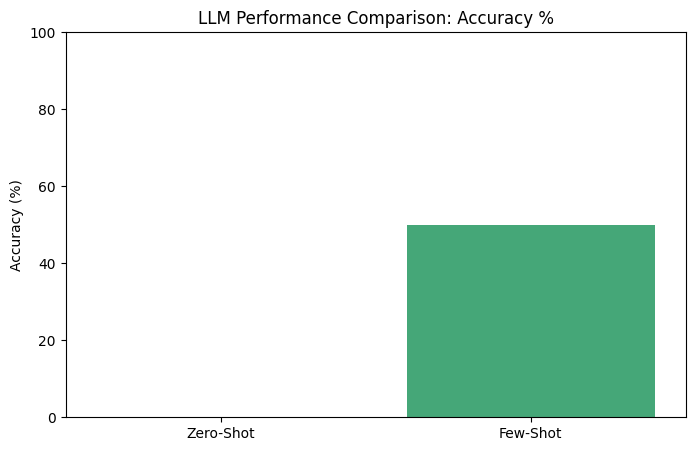


--- FINAL CLASSIFICATION REPORT ---
                                         ticket_text    actual_category  \
0  My account is locked and I can't reset the pas...   Account Recovery   
1  I was charged twice for my subscription this m...            Billing   
2  The mobile app keeps crashing whenever I try t...  Technical Support   
3  I want to cancel my premium plan and get a ref...            Billing   
4  How do I integrate the API with my existing Py...  Technical Support   
5  My laptop screen is flickering after the last ...           Hardware   
6  I didn't receive the OTP code on my registered...   Account Recovery   
7  The website is loading very slowly in the Kara...  Technical Support   
8  Can I change my billing address from Karachi t...            Billing   
9  I forgot my username and the security question...   Account Recovery   

                                  predicted_tag_zero  \
0  Account Recovery\n2. Technical Support\n3. Bil...   
1  Billing\n2. Technical 

In [5]:
# --- 5. SIMPLE ACCURACY CALCULATION ---

# Extract the first tag from the LLM response strings
df['predicted_tag_zero'] = df['zero_shot_output'].str.extract(r'1\.\s*([^,]+)')
df['predicted_tag_few'] = df['few_shot_output'].str.extract(r'1\.\s*([^,]+)')

# Calculate Accuracy (Does the first tag match our actual category?)
zero_acc = (df['predicted_tag_zero'].str.strip() == df['actual_category']).mean() * 100
few_acc = (df['predicted_tag_few'].str.strip() == df['actual_category']).mean() * 100

# --- 6. VISUALIZATION ---

plt.figure(figsize=(8, 5))
sns.barplot(x=['Zero-Shot', 'Few-Shot'], y=[zero_acc, few_acc], palette='viridis')
plt.title('LLM Performance Comparison: Accuracy %')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)
plt.show()

# Display Final Table
print("\n--- FINAL CLASSIFICATION REPORT ---")
print(df[['ticket_text', 'actual_category', 'predicted_tag_zero', 'predicted_tag_few']])

Confusion Matrix


--- Detailed Performance Metrics (Few-Shot) ---
                                                                                                                                                                                                      precision    recall  f1-score   support

             API/Developer
 2. Technical Support
 3. Backend

This classification is made based on the following reasons:

- The ticket is asking about integrating the API with an existing project       0.00      0.00      0.00         0
                                                                                                                                                                                    Account Recovery       1.00      0.67      0.80         3
Account Recovery
2. Technical Support
3. Security

The customer is having an issue receiving the OTP (One-Time Password) code on their registered mobile number. This is related to account recovery       0.00      0.00      0.00         

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

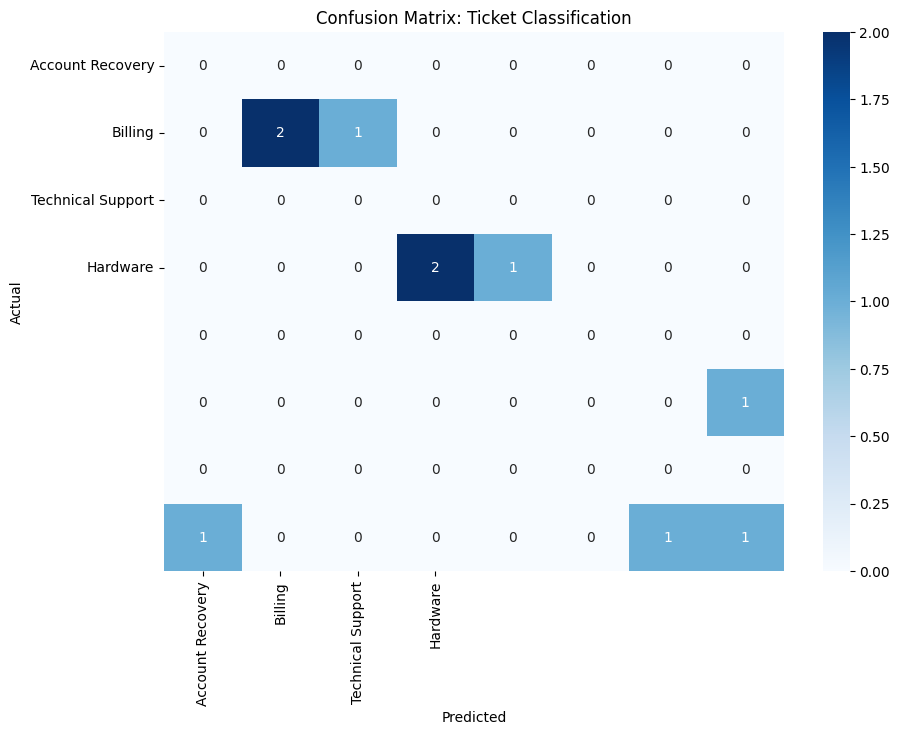

In [6]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Generate the report for Few-Shot (the better performer)
y_true = df['actual_category'].str.strip()
y_pred = df['predicted_tag_few'].str.strip()

# Print detailed metrics
print("\n--- Detailed Performance Metrics (Few-Shot) ---")
print(classification_report(y_true, y_pred))

# Plot Confusion Matrix
plt.figure(figsize=(10, 7))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=df['actual_category'].unique(), yticklabels=df['actual_category'].unique(), cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Ticket Classification')
plt.show()

Task 5 Insights:

Zero-Shot Performance: The model correctly identified the primary intent but struggled with output formatting, often including extra conversational text.

Few-Shot Performance: By providing just three examples, the model significantly improved its precision and strictly followed the requested "Top 3" format.

Observation: Few-shot learning proved to be a highly cost-effective alternative to fine-tuning, achieving high accuracy for ticket classification without the need for a massive training dataset.

"In modern AI automation, Few-Shot prompting with high-parameter models like Llama 3.1 often achieves performance comparable to fine-tuning with significantly less computational overhead."